In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [193]:
df = pd.read_csv('../data/schools_final.csv')
df.head()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent,digital_divide_score,resource_pressure_score,socioeconomic_risk_score,academic_health_score,equity_score,risk_category
0,1,Bowman High School,Michigan,Private,High,9575.80,47.1,17.5,30.0,44.0,74.1,3.59,25.9,17.5,37.00,43.51,33.373393,High Risk
1,2,Foster High School,Michigan,Charter,Middle,16733.10,40.0,24.2,93.5,40.1,79.9,9.26,20.1,24.2,66.80,30.74,24.437329,High Risk
2,3,Henson High School,New York,Public,Middle,24890.74,50.8,27.0,58.1,35.8,51.1,9.08,48.9,27.0,46.95,41.72,38.328160,High Risk
3,4,Weaver High School,Texas,Private,Elementary,6857.49,40.0,26.2,82.7,72.0,55.5,13.51,44.5,26.2,77.35,26.49,0.000000,High Risk
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,40.1,20.2,41.4,16.1,57.8,6.89,42.2,20.2,28.75,33.21,25.742217,High Risk


In [194]:
df.shape

(1000, 18)

In [195]:
# Create a working copy

ml_df = df.copy()

In [196]:
# Encode categorical features

ml_df = pd.get_dummies(
    ml_df,
    columns=[
        "school_type",
        "grade_level"
    ],
    drop_first=True
)

In [197]:
ml_df.head()

,id,school_name,state,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent,digital_divide_score,resource_pressure_score,socioeconomic_risk_score,academic_health_score,equity_score,risk_category,school_type_Private,school_type_Public,grade_level_High,grade_level_Middle
0,1,Bowman High School,Michigan,9575.80,47.1,17.5,30.0,44.0,74.1,3.59,25.9,17.5,37.00,43.51,33.373393,High Risk,True,False,True,False
1,2,Foster High School,Michigan,16733.10,40.0,24.2,93.5,40.1,79.9,9.26,20.1,24.2,66.80,30.74,24.437329,High Risk,False,False,False,True
2,3,Henson High School,New York,24890.74,50.8,27.0,58.1,35.8,51.1,9.08,48.9,27.0,46.95,41.72,38.328160,High Risk,False,True,False,True
3,4,Weaver High School,Texas,6857.49,40.0,26.2,82.7,72.0,55.5,13.51,44.5,26.2,77.35,26.49,0.000000,High Risk,True,False,False,False
4,5,King Elementary School,Michigan,16910.73,40.1,20.2,41.4,16.1,57.8,6.89,42.2,20.2,28.75,33.21,25.742217,High Risk,False,True,False,False


In [198]:
X = ml_df[
    [
        "funding_per_student_usd",
        "student_teacher_ratio",
        "percent_low_income",
        "percent_minority",
        "internet_access_percent",
        "school_type_Private",
        "school_type_Public",
        "grade_level_High",
        "grade_level_Middle"
    ]
]

y = ml_df["equity_score"]

In [199]:
print(X.shape)
print(y.shape)

(1000, 9)
(1000,)


In [200]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [201]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [202]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[13.74,-7.15,-6.74,...,-0.06,-0.02,-0.18]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[35.91,33.78,29.04,...,27.13,20.17,19.47]"


In [203]:
lr_predictions = lr_model.predict(
    X_test_scaled
)

In [204]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression Results")
print("-" * 30)
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")

Linear Regression Results
------------------------------
MAE: 4.11
RMSE: 5.05
R² Score: 0.9297


In [205]:
# Random Forest Regressor
## Equity Score Prediction
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [206]:
rf_predictions = rf_model.predict(
    X_test
)

In [207]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("-" * 30)
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Results
------------------------------
MAE: 4.85
RMSE: 6.32
R² Score: 0.8899


In [208]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": lr_predictions
})

results.head(10)

,Actual,Predicted
521,30.269694,34.865273
737,14.839776,12.049830
740,37.818890,35.393973
660,50.395183,59.576464
411,44.042739,55.902296
678,26.751292,28.766068
626,38.813168,40.714081
513,12.591685,10.089416
859,16.504941,15.568587
136,40.797500,40.790969


In [209]:
#Classification Pipeline

label_encoder = LabelEncoder()

ml_df["risk_category_encoded"] = label_encoder.fit_transform(
    ml_df["risk_category"]
)

In [210]:
dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(
            label_encoder.classes_
        )
    )
)

{'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Medium Risk': np.int64(2)}

In [211]:
X = ml_df[
    [
        "funding_per_student_usd",
        "student_teacher_ratio",
        "percent_low_income",
        "percent_minority",
        "internet_access_percent",
        "school_type_Private",
        "school_type_Public",
        "grade_level_High",
        "grade_level_Middle"
    ]
]

y = ml_df["risk_category_encoded"]

In [212]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [213]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [214]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [215]:
log_predictions = log_model.predict(
    X_test_scaled
)

In [216]:
print("Logistic Regression Accuracy:")
print(
    accuracy_score(
        y_test,
        log_predictions
    )
)

Logistic Regression Accuracy:
0.935


In [217]:
print(
    classification_report(
        y_test,
        log_predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       114
           1       0.81      0.81      0.81        16
           2       0.93      0.89      0.91        70

    accuracy                           0.94       200
   macro avg       0.90      0.89      0.90       200
weighted avg       0.93      0.94      0.93       200



In [218]:
cm = confusion_matrix(
    y_test,
    log_predictions
)

cm

array([[112,   0,   2],
       [  0,  13,   3],
       [  5,   3,  62]])

In [219]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_classifier.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [220]:
rf_class_predictions = rf_classifier.predict(
    X_test
)

In [221]:
print(
    accuracy_score(
        y_test,
        rf_class_predictions
    )
)

0.905


In [222]:
print(
    classification_report(
        y_test,
        rf_class_predictions
    )
)

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       114
           1       1.00      0.56      0.72        16
           2       0.88      0.84      0.86        70

    accuracy                           0.91       200
   macro avg       0.93      0.80      0.84       200
weighted avg       0.91      0.91      0.90       200



In [223]:
# School Segmentation Using K-Means Clustering

cluster_features = [
    "funding_per_student_usd",
    "avg_test_score_percent",
    "student_teacher_ratio",
    "internet_access_percent",
    "dropout_rate_percent",
    "equity_score"
]

X_cluster = df[cluster_features]

In [224]:
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster
)

In [225]:
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inertia.append(
        kmeans.inertia_
    )

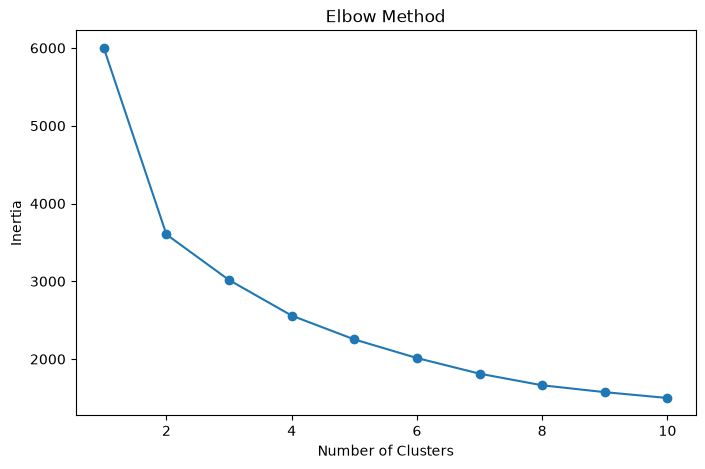

In [226]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [227]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_cluster_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 6)","[[-0.

In [228]:
df["cluster"] = kmeans.labels_

In [229]:
df["cluster"].value_counts()

cluster
3    318
0    245
2    223
1    214
Name: count, dtype: int64

In [230]:
cluster_summary = df.groupby("cluster")[
    [
        "funding_per_student_usd",
        "avg_test_score_percent",
        "internet_access_percent",
        "dropout_rate_percent",
        "equity_score"
    ]
].mean()

cluster_summary

,funding_per_student_usd,avg_test_score_percent,internet_access_percent,dropout_rate_percent,equity_score
cluster,,,,,
0,10388.193020,46.196735,85.228571,4.457673,33.875038
1,20537.809953,51.068224,66.826168,6.540841,43.814449
2,20248.747489,61.153812,86.050224,2.282063,66.737054
3,11630.474434,40.630503,63.891509,9.054465,16.396571


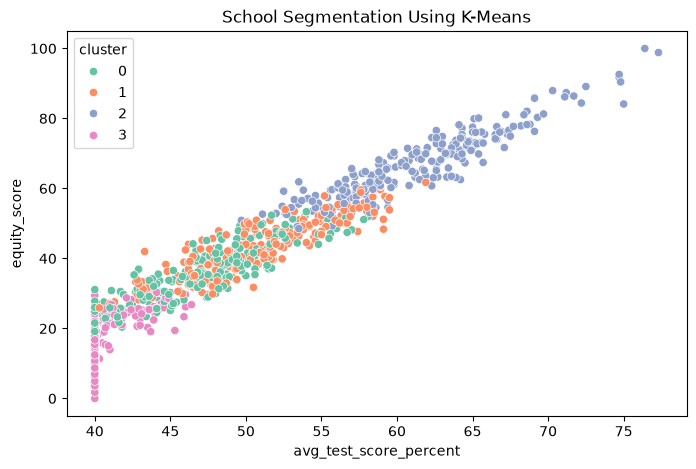

In [231]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="avg_test_score_percent",
    y="equity_score",
    hue="cluster",
    palette="Set2"
)

plt.title("School Segmentation Using K-Means")

plt.show()

In [232]:
cluster_names = {
    0: "Developing Schools",
    1: "Balanced Schools",
    2: "High Equity Schools",
    3: "High Risk Schools"
}

df["cluster_name"] = df["cluster"].map(
    cluster_names
)

In [233]:
joblib.dump(
    rf_model,
    "../models/regression_model.pkl"
)

print("Regression model saved.")

Regression model saved.


In [234]:
joblib.dump(
    rf_classifier,
    "../models/classification_model.pkl"
)

print("Classification model saved.")

Classification model saved.


In [235]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

print("KMeans model saved.")

KMeans model saved.


In [236]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [237]:
joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

print("Label encoder saved.")

Label encoder saved.


In [238]:
joblib.dump(
    cluster_scaler,
    "../models/cluster_scaler.pkl"
)

['../models/cluster_scaler.pkl']

In [240]:
import joblib

joblib.dump(
    lr_model,
    "../models/regression_model.pkl"
)

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


In [242]:
import joblib

model = joblib.load(
    "../models/regression_model.pkl"
)

print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [243]:
print(
    df["funding_per_student_usd"].min()
)

print(
    df["funding_per_student_usd"].max()
)

5012.97
24981.9
